In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Valores nulos por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Tipos de datos:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object
Maximos: [59.6 21.5]
Minimos: [32.1 13.1]
Primeros valores normalizados:
[[-0.89604189  0.7807321 ]
 [-0.82278787  0.11958397]
 [-0.67627982  0.42472926]
 [-1.33556603  1.0858774 ]
 [-0.85941488  1.74702554]]
Cantidad con pico mayor al promedio: 171


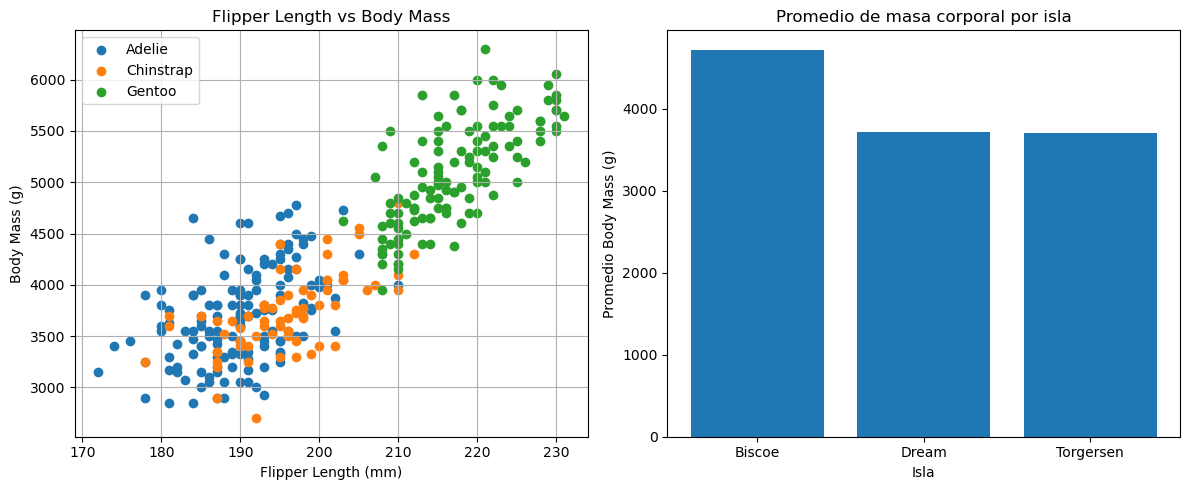

In [5]:
#Parte 1 Ingesta y limpieza con Pandas
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

#importamos los datos
df = pd.read_csv(url)
#Examinamos los valores nulos y tipo de datos
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nTipos de datos:")
print(df.dtypes)


#Limpiar datos de sexo y masa corporal 

df = df.dropna(subset=["sex", "body_mass_g"])

# Reemplazo de datos nulos por la mediana
df["bill_length_mm"] = df["bill_length_mm"].fillna(df["bill_length_mm"].median())
df["bill_depth_mm"] = df["bill_depth_mm"].fillna(df["bill_depth_mm"].median())

df["bmi_simple"] = df["body_mass_g"] / df["flipper_length_mm"]


#Parte 2 analisis estadistico con Numpy

#Cambio de dato a matriz
M_picos = df[["bill_length_mm", "bill_depth_mm"]].to_numpy()

# Maximo y minimo de la matriz con axis
maximos = np.max(M_picos, axis=0)
minimos = np.min(M_picos, axis=0)

print("Maximos:", maximos)
print("Minimos:", minimos)


media = np.mean(M_picos, axis=0)
std = np.std(M_picos, axis=0)

Z = (M_picos - media) / std

print("Primeros valores normalizados:")
print(Z[:5])

promedio_global = np.mean(df["bill_length_mm"])

condicion = df["bill_length_mm"] > promedio_global

df_longer_bills = df[condicion]

print("Cantidad con pico mayor al promedio:", condicion.sum())


#Parte 3 Comunicacion visual Matplotlib

fig, axes = plt.subplots(1, 2, figsize=(12,5))

species = df["species"].unique()

for sp in species:
    
    subset = df[df["species"] == sp]

    axes[0].scatter(
        subset["flipper_length_mm"],
        subset["body_mass_g"],
        label=sp
    )

axes[0].set_xlabel("Flipper Length (mm)")
axes[0].set_ylabel("Body Mass (g)")
axes[0].set_title("Flipper Length vs Body Mass")
axes[0].grid(True)
axes[0].legend()

promedio_isla = df.groupby("island")["body_mass_g"].mean()

axes[1].bar(promedio_isla.index, promedio_isla.values)

axes[1].set_xlabel("Isla")
axes[1].set_ylabel("Promedio Body Mass (g)")
axes[1].set_title("Promedio de masa corporal por isla")


plt.tight_layout()
plt.show()